# Advanced Annotations and Legends

When you create a chart for a presentation or a client, they might not understand which point is the most important. A good plot should "tell a story" on its own.

*   **Annotations** are text labels with arrows pointing directly to a specific coordinate $(x, y)$ on your chart. They allow you to say: "Look at this specific spot! This is where our server crashed" or "This is our highest sales point."
*   **Legend Customization**: By default, Matplotlib places the legend box inside the chart. If you have many lines, the legend box might cover up some data points. We will learn how to use `bbox_to_anchor` to move the legend cleanly **outside** the chart box, so your data remains 100% visible.

### Simple Explanation with an Everyday Analogy
*   **Annotation**: Imagine sticking a yellow post-it note with a hand-drawn arrow pointing to a specific day on a wall calendar, writing: *"My Birthday! 🎂"*.
*   **Bbox to Anchor Legend**: Imagine putting the description label of an artwork on the gallery wall *right next to* the painting, instead of sticking the paper directly onto the painting canvas.

#### Placing an Arrow Annotation pointing to a Specific Point
We use `plt.annotate()` to place a text callout on our graph.
*   `text`: The string label.
*   `xy`: The coordinate tuple $(x, y)$ where the arrow points.
*   `xytext`: The coordinate tuple where the text label should be written.
*   `arrowprops`: A dictionary defining arrow style and colors.


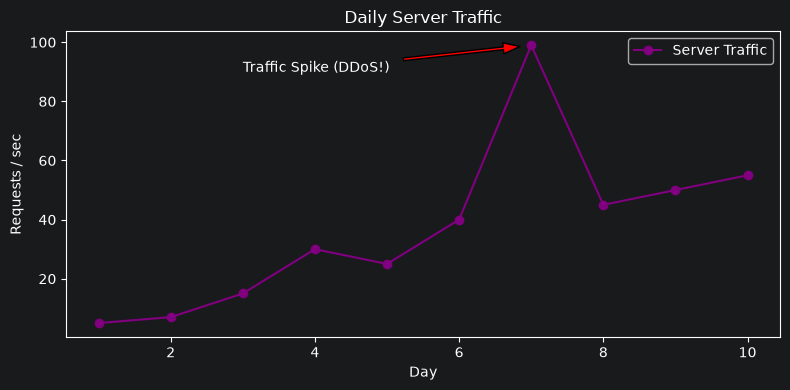

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1, 11)
y = np.array([5, 7, 15, 30, 25, 40, 99, 45, 50, 55]) # 99 is a massive spike at index 6

plt.figure(figsize=(8, 4))
plt.plot(x, y, marker='o', color='purple', label="Server Traffic")

# Add Annotation pointing to the spike (index 6, which is x=7, y=99)
plt.annotate(
    'Traffic Spike (DDoS!)',
    xy=(7, 99),
    xytext=(3, 90),
    arrowprops=dict(facecolor='red', shrink=0.08, width=2, headwidth=8)
)

plt.title("Daily Server Traffic")
plt.xlabel("Day")
plt.ylabel("Requests / sec")
plt.legend()
plt.tight_layout()
# plt.savefig('traffic_annotation.png')

#### Positioning the Legend Outside the Chart
To move the legend outside the bounding box of your plot, use the `bbox_to_anchor` parameter in `plt.legend()`.
*   `bbox_to_anchor=(1.05, 1)` means: place the legend slightly to the right of the plot boundary (`1.05` on X-axis where `1.0` is the edge) and align it with the top edge (`1.0` on Y-axis).
*   `loc='upper left'` means the top-left corner of the legend box anchors at that coordinate.


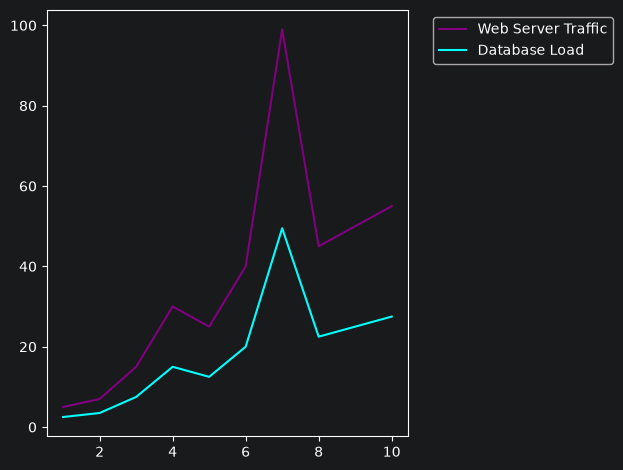

In [2]:
plt.plot(x, y, label="Web Server Traffic", color="purple")
plt.plot(x, y * 0.5, label="Database Load", color="cyan")

# Move legend box outside to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

### Common Mistakes Beginners Make
1.  **Forgetting to set `bbox_inches='tight'` when saving**: When you move a legend outside the plot box using `bbox_to_anchor`, Matplotlib might cut the legend out of the saved image file. Always write `plt.savefig('name.png', bbox_inches='tight')` to prevent this.
2.  **Confusing `xy` and `xytext` inside `plt.annotate()`**:
    *   `xy` is the point you are pointing *to* (the data point).
    *   `xytext` is where the text label itself is placed on the coordinate grid.


#### Exercise 1 (Easy)
Create a plot of a line passing through `x = [1, 2, 3, 4]` and `y = [10, 20, 15, 40]`. Add a basic text annotation (without an arrow) at coordinate `(4, 40)` saying `"Peak Performance"`.
*Hint: Use `plt.text(x, y, "string")` or `plt.annotate("string", xy=(x, y))` with no arrowprops.*

Text(0.5, 1.0, 'Simple Callout')

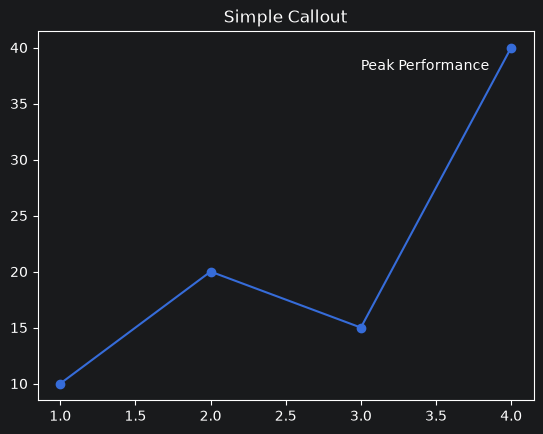

In [3]:
import matplotlib.pyplot as plt
x = [1, 2, 3, 4]
y = [10, 20, 15, 40]

plt.plot(x, y, marker='o')
plt.annotate("Peak Performance", xy=(4, 40), xytext=(3, 38))
plt.title("Simple Callout")

#### Exercise 2 (Medium)
Given two lines representing two servers:
```python
days = np.arange(1, 6)
server_a = [90, 92, 95, 91, 93]
server_b = [40, 45, 88, 50, 48]
```
Plot both lines. Add an arrow annotation pointing to Server B's spike on Day 3 `(3, 88)` with the text `"Patch Applied"`. Move the legend outside to the right side of the plot.


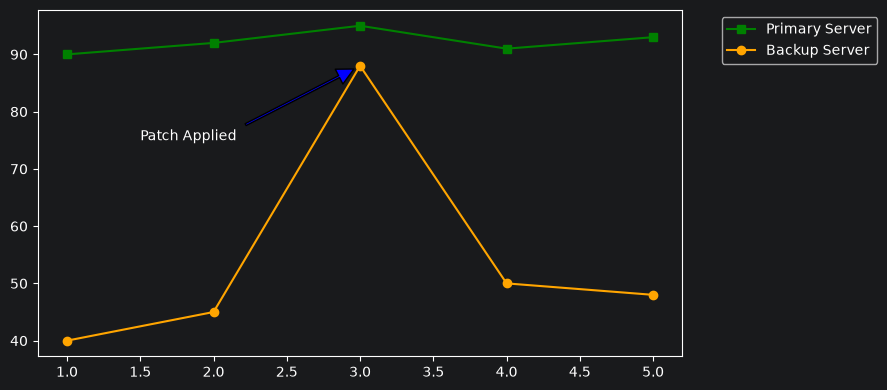

In [4]:
import matplotlib.pyplot as plt
import numpy as np

days = np.arange(1, 6)
server_a = [90, 92, 95, 91, 93]
server_b = [40, 45, 88, 50, 48]

plt.figure(figsize=(9, 4))
plt.plot(days, server_a, label="Primary Server", color='green', marker='s')
plt.plot(days, server_b, label="Backup Server", color='orange', marker='o')

# Arrow Annotation
plt.annotate(
    "Patch Applied",
    xy=(3, 88),
    xytext=(1.5, 75),
    arrowprops=dict(facecolor='blue', shrink=0.05, width=1.5)
)

# Position Legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig('backup_server.png', bbox_inches='tight')